# Sensor Frequency Responses

This notebook loads every sensor response CSV from `data/frequency-responses/` and plots the curves overlapped on a single figure so inter-sensor variation is easy to compare.

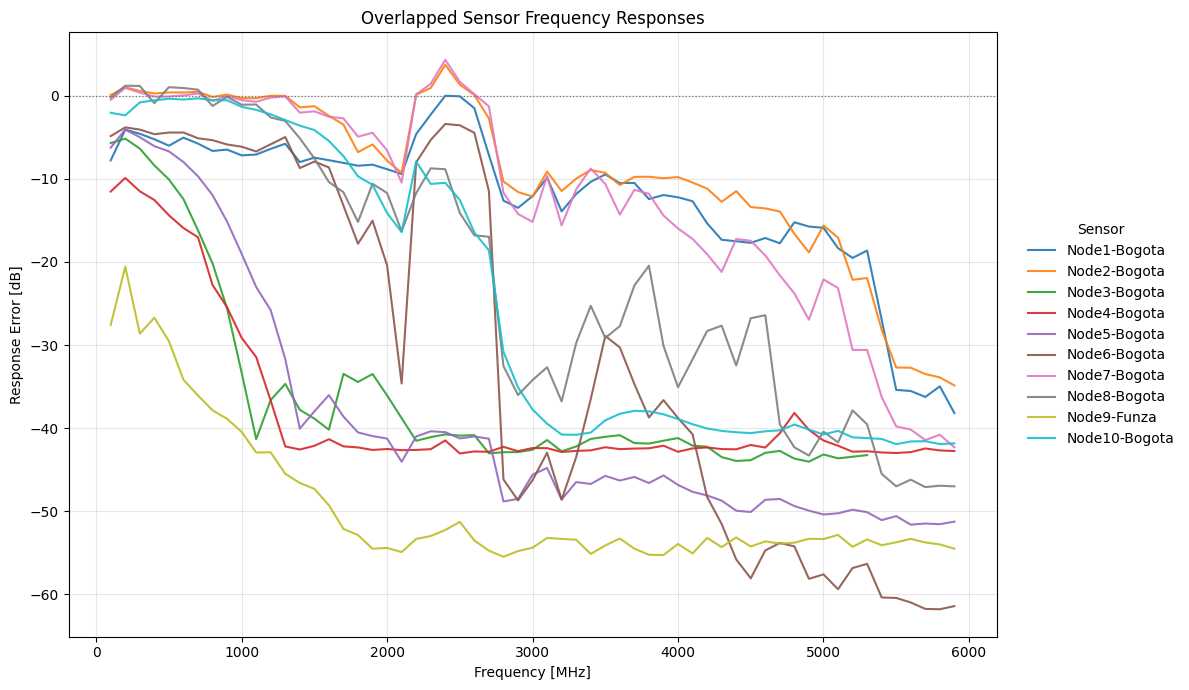

In [1]:
from __future__ import annotations

import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_response_directory(
    start_dir: Path,  # Directory from which to start the repository search
) -> Path:  # Directory containing the per-sensor response CSV files
    """Locate the response directory by walking upward from the execution path.

    Parameters
    ----------
    start_dir:
        Directory from which the notebook starts looking for
        `data/frequency-responses`.

    Returns
    -------
    Path
        Absolute path to the frequency-response CSV directory.

    Raises
    ------
    FileNotFoundError
        If the response directory cannot be found in the current directory
        or any parent directory.
    """

    # Accept both repo-root and notebooks-directory execution contexts.
    for candidate_dir in (start_dir, *start_dir.parents):
        response_dir = candidate_dir / "data" / "frequency-responses"
        if response_dir.exists():
            return response_dir.resolve()

    raise FileNotFoundError(
        "Could not locate data/frequency-responses from the current working directory."
    )


def natural_sensor_key(
    response_path: Path,  # Path of one sensor response CSV file
) -> tuple[int, str]:  # Natural-order key that keeps Node10 after Node9
    """Return a natural sort key for sensor response filenames."""

    match = re.search(r"Node(\d+)", response_path.stem)
    if match is None:
        return (10**9, response_path.stem)
    return (int(match.group(1)), response_path.stem)


def load_response_curve(
    response_path: Path,  # CSV path with `central_freq_hz` and `error_dB` columns
) -> tuple[np.ndarray, np.ndarray, str]:  # Frequency [Hz], response [dB], and sensor ID
    """Load one sensor frequency-response curve from disk.

    Parameters
    ----------
    response_path:
        CSV file that stores the sparse response sweep for one sensor.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, str]
        Frequency samples in hertz, response error in decibels, and the
        sensor identifier derived from the filename.

    Side Effects
    ------------
    Reads one CSV file from disk.

    Raises
    ------
    ValueError
        If the file does not contain any numeric response rows.
    """

    frequency_hz: list[float] = []
    error_db: list[float] = []
    with response_path.open(newline="") as csv_file:
        for row in csv.DictReader(csv_file):
            try:
                frequency_hz.append(float(row["central_freq_hz"]))
                error_db.append(float(row["error_dB"]))
            except (TypeError, ValueError):
                continue

    if not frequency_hz:
        raise ValueError(f"No numeric response rows were found in {response_path}")

    frequency_hz_array = np.asarray(frequency_hz, dtype=np.float64)
    error_db_array = np.asarray(error_db, dtype=np.float64)

    # Sort by frequency to guarantee a monotonic x-axis even if the CSV order changes.
    order = np.argsort(frequency_hz_array)
    sensor_id = response_path.name.removesuffix("-response.csv")
    return frequency_hz_array[order], error_db_array[order], sensor_id


response_dir = find_response_directory(Path.cwd())
response_paths = sorted(response_dir.glob("*-response.csv"), key=natural_sensor_key)
if not response_paths:
    raise FileNotFoundError(f"No response CSV files were found in {response_dir}")

figure, axis = plt.subplots(figsize=(12, 7))

# Plot every sensor on the same axes so response-shape differences are directly comparable.
for response_path in response_paths:
    frequency_hz, response_db, sensor_id = load_response_curve(response_path)
    axis.plot(
        frequency_hz / 1e6,
        response_db,
        linewidth=1.5,
        alpha=0.9,
        label=sensor_id,
    )

axis.axhline(0.0, color="0.45", linewidth=0.9, linestyle=":")
axis.set_title("Overlapped Sensor Frequency Responses")
axis.set_xlabel("Frequency [MHz]")
axis.set_ylabel("Response Error [dB]")
axis.grid(alpha=0.3)
axis.legend(title="Sensor", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
figure.tight_layout()
plt.show()
